# One dense Layer

In [19]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split

In [46]:
device = "cuda"

In [5]:
import h5py
keys = 'u', 'v', 'w', 'p_total'

def extract(real, keys):
    data = []
    with h5py.File("/data1/dataToYouri/couette_dns_ml_f32.h5", 'r') as f:
        for k in keys:
            data.append(np.array(f[real][k]))
        return np.stack(data, axis=1)

        
def domain():
    data = {}
    keys = ['x', 'y', 'z']
    with h5py.File("/data1/dataToYouri/couette_dns_ml_f32.h5", 'r') as f:
        for k in keys:
            data[k] = np.array(f[k])
        return data

d = extract('R3', keys)
domain = domain()
dx = domain['x'][1] - domain['x'][0]
dz = domain['z'][1] - domain['z'][0]
nx = domain['x'].shape[0]
nz = domain['z'].shape[0]
y = domain['y']

In [8]:
T, C, X, Y, Z = d.shape

In [77]:
d.shape

(4801, 4, 24, 33, 24)

In [98]:
d2 = extract('R4', keys)
d2.shape

(4801, 4, 24, 33, 24)

In [99]:
d3 = extract('R5', keys)
d3.shape

(4801, 4, 24, 33, 24)

In [123]:
model = nn.Sequential(nn.Linear(X * 1 * Z, X * Y * Z * 3)).to(device)

In [124]:
model

Sequential(
  (0): Linear(in_features=576, out_features=57024, bias=True)
)

In [31]:
X * 1 * Z

576

In [32]:
x = torch.from_numpy(d[0:1, 3, :, 0, :].ravel())
x.shape

torch.Size([576])

In [122]:
pred = model(x)

In [34]:
pred.shape

torch.Size([57024])

In [100]:
class DS(Dataset):
    def __init__(self, d):
        self.x = torch.from_numpy(d[:, 3, :, 0, :]).float().reshape(-1, X * 1 * Z).to(device)
        self.y = torch.from_numpy(d[:, :3, :, :, :]).float().reshape(-1, X * Y * Z * 3).to(device)
    def __len__(self):
        return self.x.shape[0]
    def __getitem__(self, i):
        return self.x[i], self.y[i]

In [101]:
train_ds = DS(d)
test_ds = DS(d2[:500]) 
val_ds = DS(d3[:500])

In [102]:
def train(model, opti, loss, ds):
    model.train()
    total_loss = 0
    for x, y in ds:
        opti.zero_grad()
        pred = model(x)
        l = loss(y, pred)
        total_loss += l.item()
        l.backward()
        opti.step()
    return total_loss / len(ds)

In [103]:
def test(model, loss, ds):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x, y in ds:
            pred = model(x)
            l = loss(y, pred)
            total_loss += l.item()
    return total_loss / len(ds)

In [135]:

batch_size = 4
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

lr = 1e-3
opti = torch.optim.Adam(model.parameters(), lr=lr)

In [136]:
import trackio

epochs = 20
loss = nn.MSELoss(reduction='mean')

trackio.init(
    project="mlp-1",
    config={"epochs": epochs, "learning_rate": lr, "batch_size": batch_size}
)
for epoch in range(epochs):
    train_error = train(model, opti, loss, train_dl)
    test_error = test(model, loss, test_dl)

    trackio.log({
        "epoch": epoch,
        "train_error": train_error,
        "test_error": test_error,
    })

trackio.finish()

* Created new run: calm-river-2
* Run finished. Uploading logs to Trackio (please wait...)


In [106]:
val_error = test(model, loss, val_dl)

In [107]:
val_error

0.01725900663435459

In [108]:
x, y = val_dl.dataset[100]

In [109]:
y.shape

torch.Size([57024])

In [110]:
yb = y.reshape(3, X, Y, Z)

In [111]:
yb.shape

torch.Size([3, 24, 33, 24])

In [112]:
yc = yb.cpu()

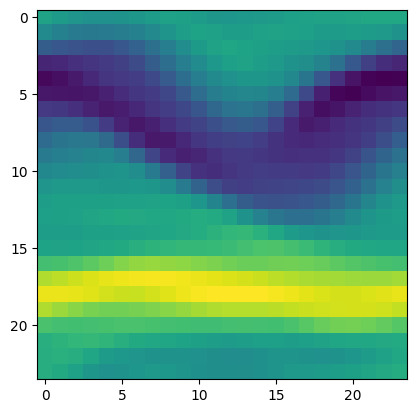

In [113]:
import matplotlib.pyplot as plt
plt.imshow(yc[0, :, 15, :])

In [120]:
val_dl.dataset.y.mean()

tensor(-0.0002, device='cuda:0')

In [157]:
val_dl.dataset.y.var()

tensor(0.0403, device='cuda:0')

In [158]:
preds = model(val_dl.dataset.x)

In [159]:
preds.shape

torch.Size([500, 57024])

In [160]:
preds.var()

tensor(0.0322, device='cuda:0', grad_fn=<VarBackward0>)

In [161]:
preds.mean()

tensor(0.0009, device='cuda:0', grad_fn=<MeanBackward0>)

In [153]:
val_dl.dataset.y.shape

torch.Size([500, 57024])

In [154]:
torch.nn.functional.mse_loss(preds, val_dl.dataset.y)

tensor(0.0166, device='cuda:0', grad_fn=<MseLossBackward0>)

In [155]:
torch.nn.functional.mse_loss(preds, val_dl.dataset.y) / val_dl.dataset.y.var(unbiased=False)

tensor(0.4112, device='cuda:0', grad_fn=<DivBackward0>)